In [222]:
# Spectroscopy assignment 1
# Sibusiso Mathebula
# 23/09/2026

In [223]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
import lineid_plot
import pandas as pd


# Answering question 2 of the Spectroscopy assignment


### Defining Blackbody function for any input temperature as a function of wavelength
The units are in $W/m^2$

In [224]:
def blackbody(wavelength, temperature):
    """
    Calculate the blackbody radiation for a given wavelength and temperature.

    Parameters:
    wavelength (float or array-like): Wavelength(s) in meters.
    temperature (float): Temperature in Kelvin.

    Returns:
    float or array-like: Blackbody radiation intensity.
    """
    h = 6.62607015e-34  # Planck's constant in J*s
    c = 3.0e8           # Speed of light in m/s
    k = 1.380649e-23    # Boltzmann's constant in J/K

    # Calculate the blackbody radiation using Planck's law
    intensity = (2.0 * h * c**2) / (wavelength**5) * (1.0 / (np.exp((h * c) / (wavelength * k * temperature)) - 1.0))
    
    return intensity    # units are in W/m^2


In [225]:
def plot_function(wavelength, intensity, xlabel, ylabel,temperature,spec_class):
    """
    Plot the given wavelength and intensity data.

    Parameters:
    wavelength (array-like): Wavelength data.
    intensity (array-like): Intensity data.
    title (str): Title of the plot.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    """
    title = f"Blackbody Radiation Curve of a Star with Spectral class {spec_class} at {temperature} K " 

    plt.figure(figsize=(10, 6))
    plt.plot(wavelength, intensity, color='blue')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    plt.show()

$$
\begin{array}{|c|c|}
\hline
\textbf{Spectral Type} & \textbf{Temperature Range} \\
\hline
  O & > 25000 K \\
\hline
 B &  10000-25000 K\\
\hline
A &  7500 K - 10000 K\\
\hline
F & 6000 K - 7500 K \\
\hline
G & 5000 K - 6000 K\\
\hline
K & 3500 K - 5000 K \\
\hline
M & <3500 K\\
\hline

\end{array}
$$

In [226]:
# Defining the wavelength range and temperature for the blackbody radiation
wavelength = np.linspace(3500,9000,10000)

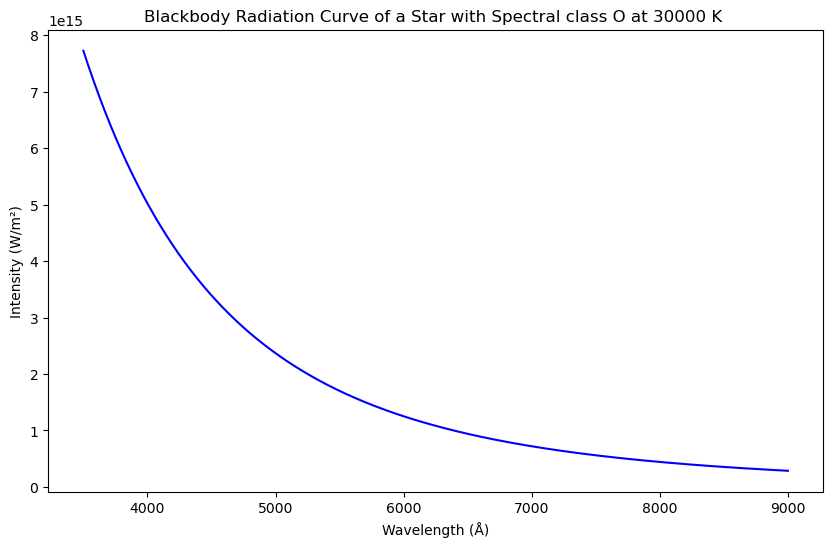

In [227]:
# Plotting the blackbody radiation curves for different temperatures and spectral classes
# Plotting for spectral class O (30,000 K)
temperature_O = 30000  # Temperature for spectral class O in Kelvin
intensity_O = blackbody(wavelength * 1e-10, temperature_O)
plot_function(wavelength, intensity_O, "Wavelength (Å)", "Intensity (W/m²)", temperature_O, "O")

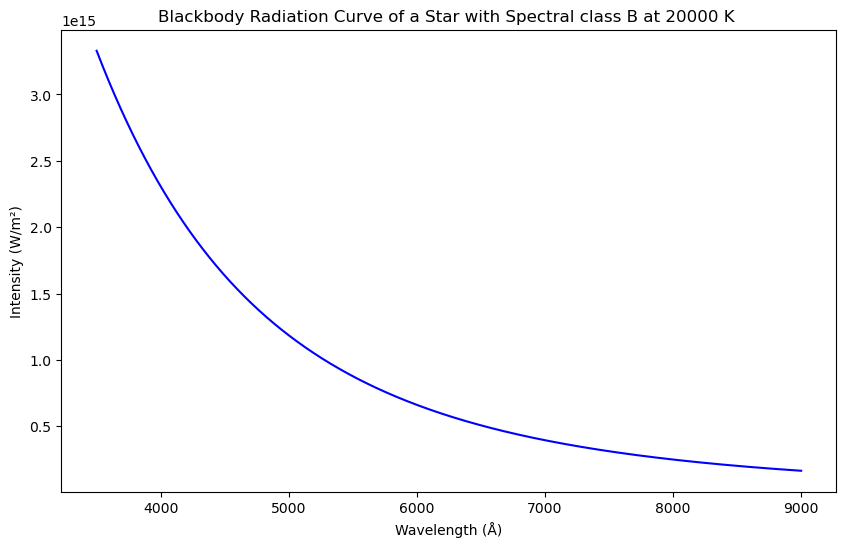

In [228]:
# Plotting for spectral class B (20,000 K)
temperature_B = 20000  # Temperature for spectral class B in Kelvin
intensity_B = blackbody(wavelength * 1e-10, temperature_B)
plot_function(wavelength, intensity_B, "Wavelength (Å)", "Intensity (W/m²)", temperature_B, "B")    

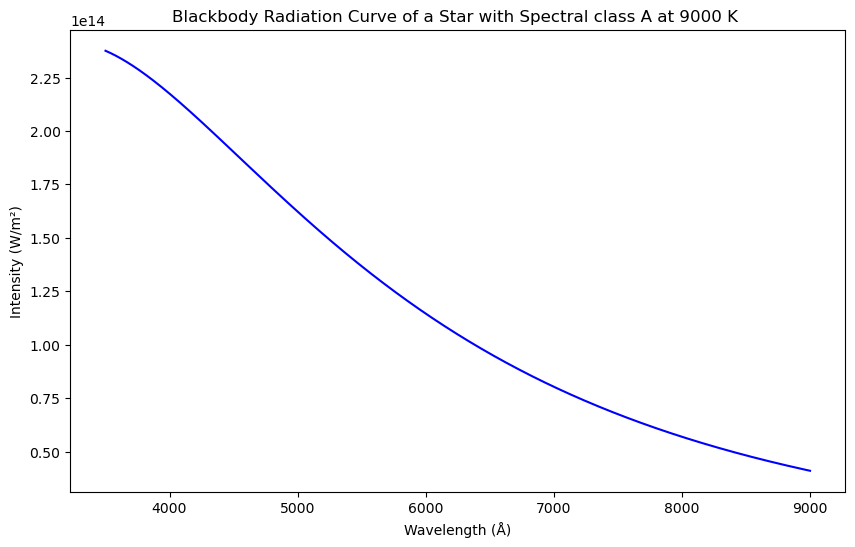

In [229]:
# Plotting for spectral class A (9000 K)
temperature_A = 9000  # Temperature for spectral class A in Kelvin
intensity_A = blackbody(wavelength * 1e-10, temperature_A)
plot_function(wavelength, intensity_A, "Wavelength (Å)", "Intensity (W/m²)", temperature_A, "A")    

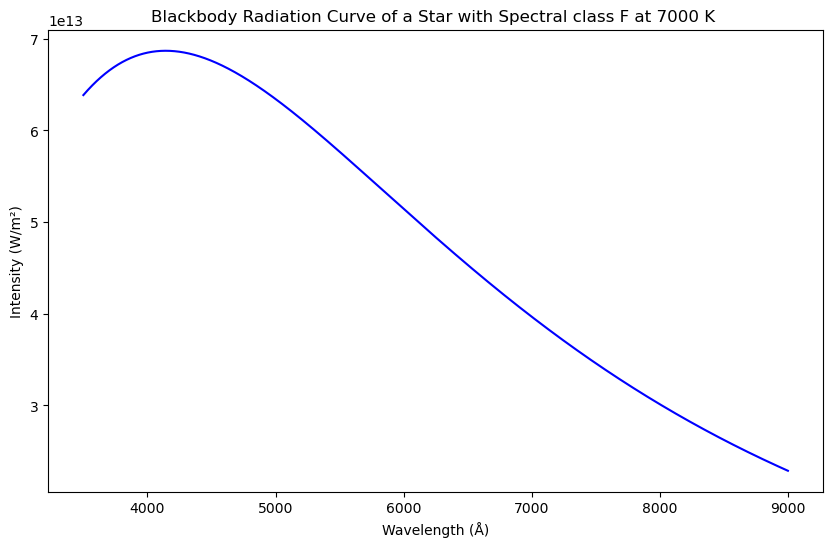

In [230]:
#Plotting for spectral class F (7000 K)
temperature_F = 7000  # Temperature for spectral class F in Kelvin
intensity_F = blackbody(wavelength * 1e-10, temperature_F)
plot_function(wavelength, intensity_F, "Wavelength (Å)", "Intensity (W/m²)", temperature_F, "F")

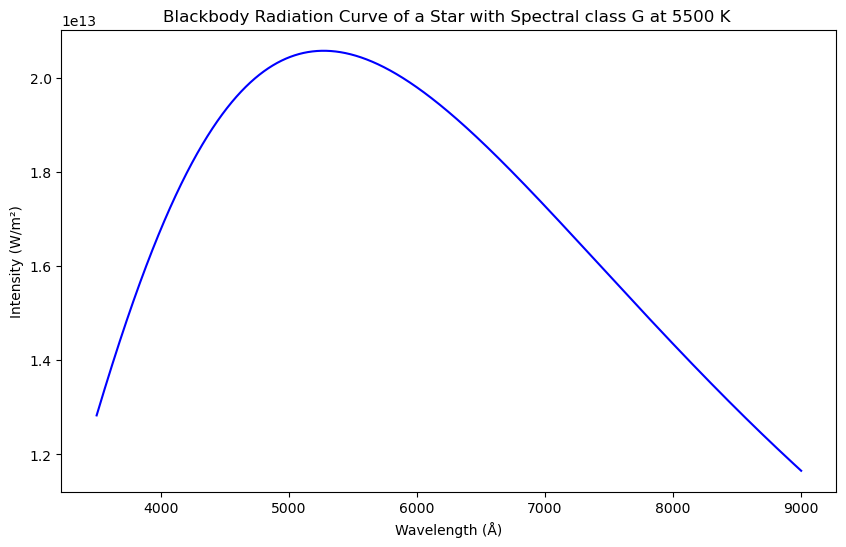

In [231]:
# Plotting for spectral class G (5,500 K)
temperature_G = 5500  # Temperature for spectral class G in Kelvin
intensity_G = blackbody(wavelength * 1e-10, temperature_G)
plot_function(wavelength, intensity_G, "Wavelength (Å)", "Intensity (W/m²)", temperature_G, "G")    

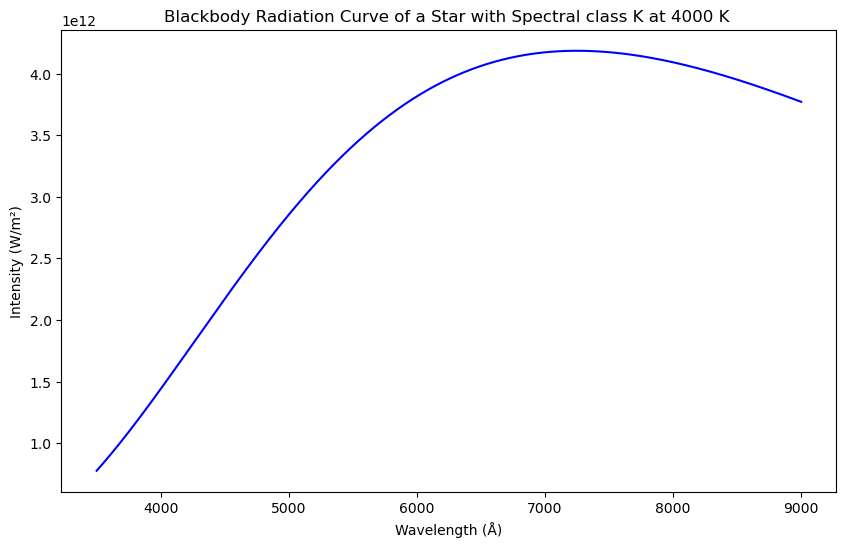

In [232]:
# Plotting for spectral class K (4000 K)
temperature_K = 4000  # Temperature for spectral class K in Kelvin
intensity_K = blackbody(wavelength * 1e-10, temperature_K)
plot_function(wavelength, intensity_K, "Wavelength (Å)", "Intensity (W/m²)", temperature_K, "K")

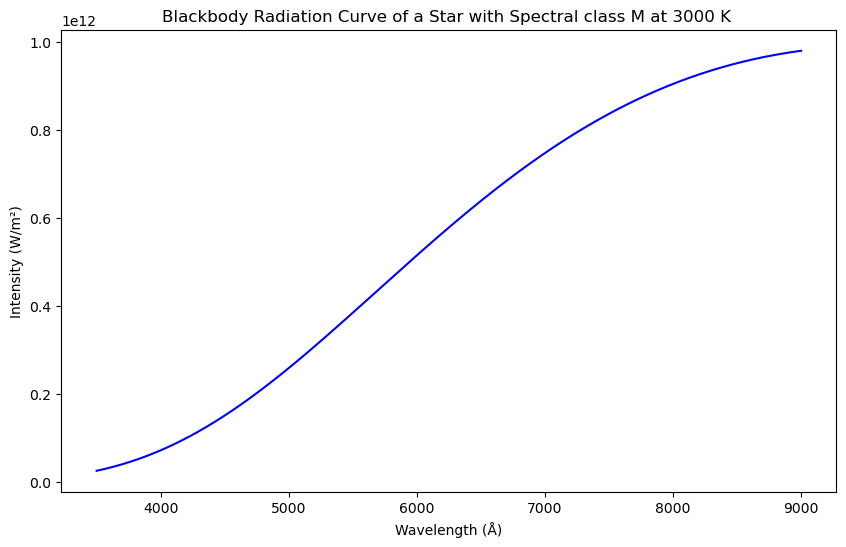

In [233]:
# Plotting for spectral class M (3000 K)
temperature_M = 3000  # Temperature for spectral class M in Kelvin
intensity_M = blackbody(wavelength * 1e-10, temperature_M)
plot_function(wavelength, intensity_M, "Wavelength (Å)", "Intensity (W/m²)", temperature_M, "M")

# Question spectral types 


In [234]:
from astropy.io import fits
flux_SI = 1e-7 / (1e-2 * 1e-10)  # factor to convert flux from erg/s/cm²/Å to W/m²/m
data = []  # flux values for each file
wavelengths =[]  # wavelength values for each file
files =['star1.fit','star2.fit','star3.fit','star4.fit','star5.fit']  # reading the FITS files
i=0
for file in files:
    hd_1 = fits.open(file)
    data.append(flux_SI * hd_1[0].data[0]) # Assuming the data is in the first extension
    print(hd_1[0].header)  # Print the header to check for wavelength information


    c_0 = hd_1[0].header['coeff0']  # Starting wavelength value from the FITS header
    c_1 = hd_1[0].header['coeff1']  # Wavelength increment from the FITS header
    j =np.arange(len(data[i]))  # Create an array of indices corresponding to the data points

    wavelength = 10**(c_0 +c_1*j)
    wavelengths.append(wavelength)
    i+=1

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 3822                                                  NAXIS2  =                    4                                                  TAI     =        4489115202.56 / 1st row - Number of seconds since Nov 17 1858  RA      =            157.90174 / 1st row - Right ascension of telescope boresighDEC     =            0.009127  / 1st row - Declination of telescope boresight (dEQUINOX =              2000.00 /                                                RADECSYS= 'FK5     '           /                                                AZ      =        341.770587574 / 1st row - Azimuth  (encoder) of tele (0=N?) (deALT     =        55.6539934715 / 1st row - Altitude (encoder) of tele        (deAIRMASS =        1.20434831374 /        

# Plotting the spectra with the absorption lines marked

In [235]:
def plot_spectrum(wavelength, intensity, xlabel, ylabel, title):
    """
    Plot the spectrum data.

    Parameters:
    wavelength (array-like): Wavelength data.
    intensity (array-like): Intensity data.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    title (str): Title of the plot.
    """
    balmer_lines = {                           # balmer series lines with their corresponding colors
        6562.8: (r'H$\alpha$', 'red'),
        4861.3: (r'H$\beta$', 'green'),
        4340.5: (r'H$\gamma$', 'orange'),
        4101.7: (r'H$\delta$', 'purple'),
        3970.1: (r'H$\epsilon$', 'brown'),
        3889.1: (r'H$\zeta$', 'cyan'),
        3835.4: (r'H$\eta$', 'magenta'),
        3797.9: (r'H$\theta$', 'black'),
        3770.6: (r'H$\iota$', 'gray'),
        3750.2: (r'H$\kappa$', 'pink')
    }
    
    for i in range(len(files)):
       plt.figure(figsize=(10, 6))
       plt.title(f"Star {i+1} Spectrum")
       plt.xlabel(xlabel)
       plt.ylabel(ylabel)
       plt.plot(wavelength[i], data[i], color='blue')
       for wl, (label, colour) in balmer_lines.items():
            if wavelength[i].min() <= wl <= wavelength[i].max():
                plt.axvline(
                    wl,
                    color=colour,
                    linestyle='--',
                    linewidth=1.5,
                    alpha=0.8,
                    label=label
                )
       plt.legend()

       plt.show()
       
    
    
    

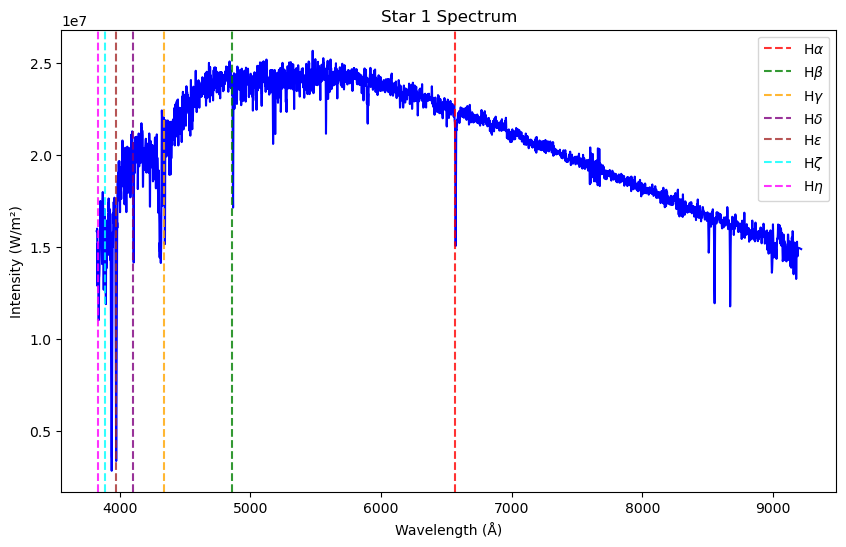

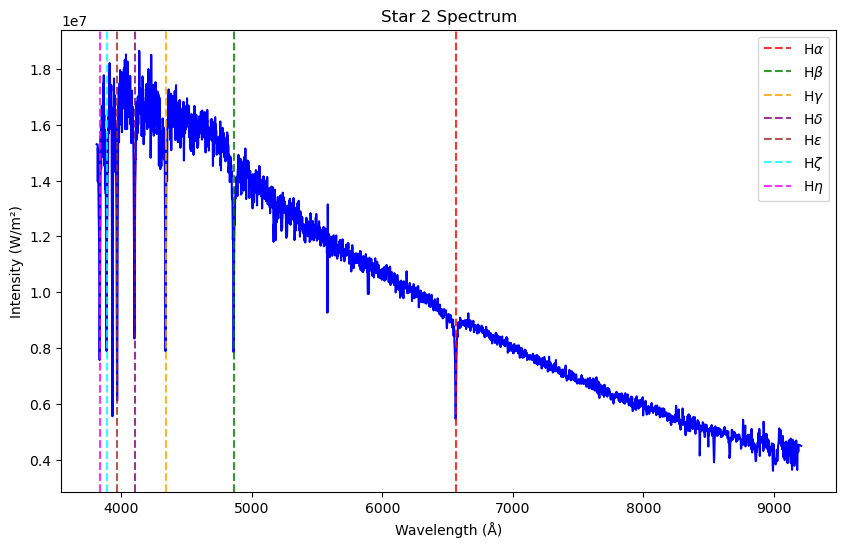

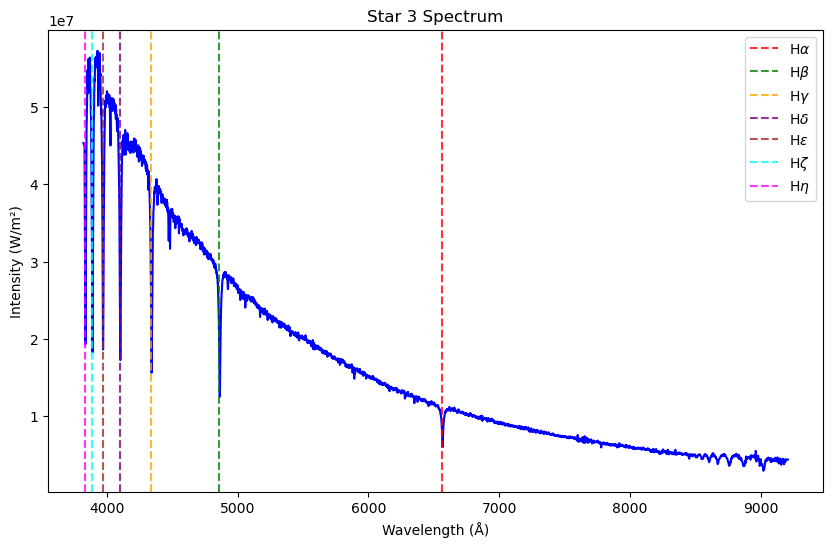

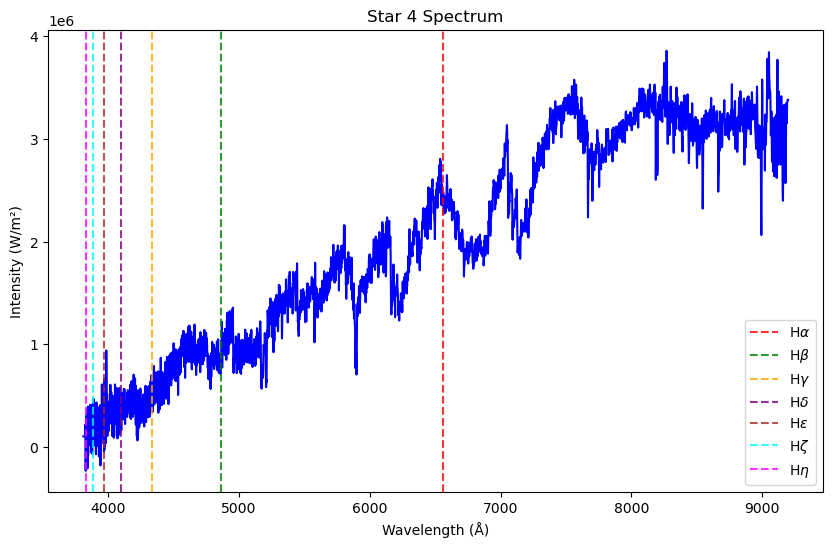

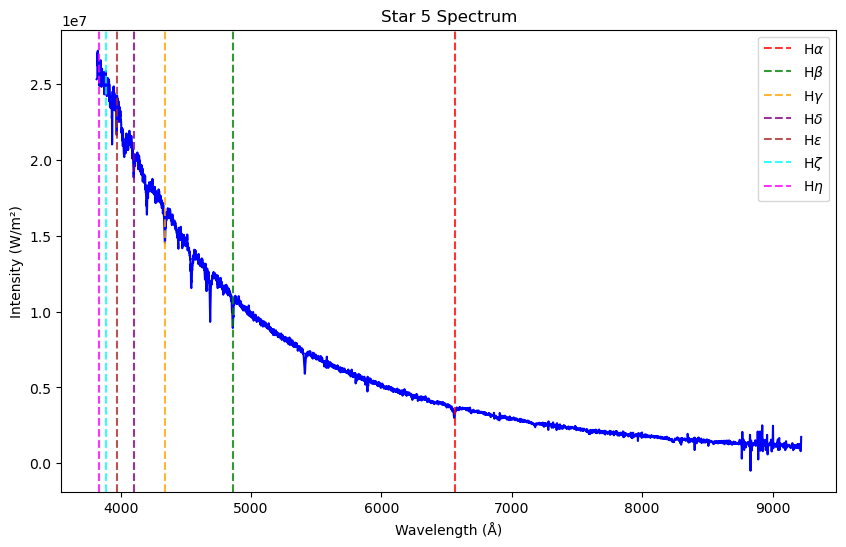

In [236]:
plot_spectrum(wavelengths, data, "Wavelength (Å)", "Intensity (W/m²)", "Spectrum of Stars")

In [237]:
def plot_spectrum_1(wavelength, intensity, xlabel, ylabel, title):

    """
    Plot the spectrum data and mark important spectral lines.

    Parameters:
    wavelength (array-like): Wavelength data.
    intensity (array-like): Intensity data.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    title (str): Title of the plot.
    """

    spectral_lines = {

        # -------------------------
        # Hydrogen Balmer series
        # -------------------------
        6562.8: (r'H$\alpha$', 'red'),
        4861.3: (r'H$\beta$', 'green'),
        4340.5: (r'H$\gamma$', 'orange'),
        4101.7: (r'H$\delta$', 'purple'),
        3970.1: (r'H$\epsilon$', 'brown'),
        3889.1: (r'H$\zeta$', 'cyan'),
        3835.4: (r'H$\eta$', 'magenta'),
        3797.9: (r'H$\theta$', 'black'),
        3770.6: (r'H$\iota$', 'gray'),
        3750.2: (r'H$\kappa$', 'pink'),

        # -------------------------
        # Helium
        # -------------------------
        4471.5: (r'He I', 'darkorange'),
        5875.6: (r'He I', 'gold'),
        6678.2: (r'He I', 'olive'),

        4685.7: (r'He II', 'darkred'),
        5411.5: (r'He II', 'darkviolet'),

        # -------------------------
        # Calcium
        # -------------------------
        3933.7: (r'Ca II K', 'navy'),
        3968.5: (r'Ca II H', 'teal'),

        # -------------------------
        # Sodium
        # -------------------------
        5889.95: (r'Na I D$_2$', 'blue'),
        5895.92: (r'Na I D$_1$', 'royalblue'),

        # -------------------------
        # Magnesium
        # -------------------------
        5172.7: (r'Mg I', 'darkgreen'),
        5183.6: (r'Mg I', 'forestgreen'),

        # -------------------------
        # Iron
        # -------------------------
        4383.5: (r'Fe I', 'saddlebrown'),
        5270.4: (r'Fe I', 'slategray'),

        
        # Oxygen / forbidden lines
        
        4958.9: (r'[O III]', 'darkcyan'),
        5006.8: (r'[O III]', 'cyan'),

       
        # Oxygen II
        
        3726.0: (r'[O II]', 'crimson'),
        3728.8: (r'[O II]', 'firebrick'),

        
        # Nitrogen
        
        6583.6: (r'[N II]', 'darkblue'),
        6548.1: (r'[N II]', 'blue'),

        
        # Sulfur
    
        6716.4: (r'[S II]', 'darkmagenta'),
        6730.8: (r'[S II]', 'magenta'),

         # UV emission lines
        1548.2: (r'C IV', 'blue'),
        1550.8: (r'C IV', 'royalblue'),
        1640.4: (r'He II', 'red'),
        1854.7: (r'Al III', 'darkgreen'),
        1862.8: (r'Al III', 'green'),
        1892.0: (r'Si III]', 'orange'),
        1908.7: (r'C III]', 'purple'),

        # Other important UV features
        1393.8: (r'[Si IV]', 'black'),
        1402.8: (r'[Si IV]', 'saddlebrown'),

        2586.7: (r'[Fe II]', 'blue'),
        2600.2: (r'[Fe II]', 'royalblue'),

        2669.2: (r'[Al II]', 'green'),

        2795.5: (r'[Mg II]', 'black'),
        2802.7: (r'[Mg II]', 'saddlebrown'),

        2852.1: (r'[Mg I]', 'purple'),

        2837.6: (r'[C II]', 'red'),
        2837.9: (r'[C II]', 'darkred'),

        
    }

    for i in range(len(wavelength)):

        plt.figure(figsize=(12, 6))

        plt.title(f"Star {i+1} Spectrum")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

        plt.plot(
            wavelength[i],
            intensity[i],
            color='blue'
        )

        for wl, (label, colour) in spectral_lines.items():

            if wavelength[i].min() <= wl <= wavelength[i].max():

                plt.axvline(
                    wl,
                    color=colour,
                    linestyle='--',
                    linewidth=1.2,
                    alpha=0.7,
                    label=label
                )

        plt.legend(
            loc='upper right',
            fontsize=8,
            ncol=2
        )

        plt.show()

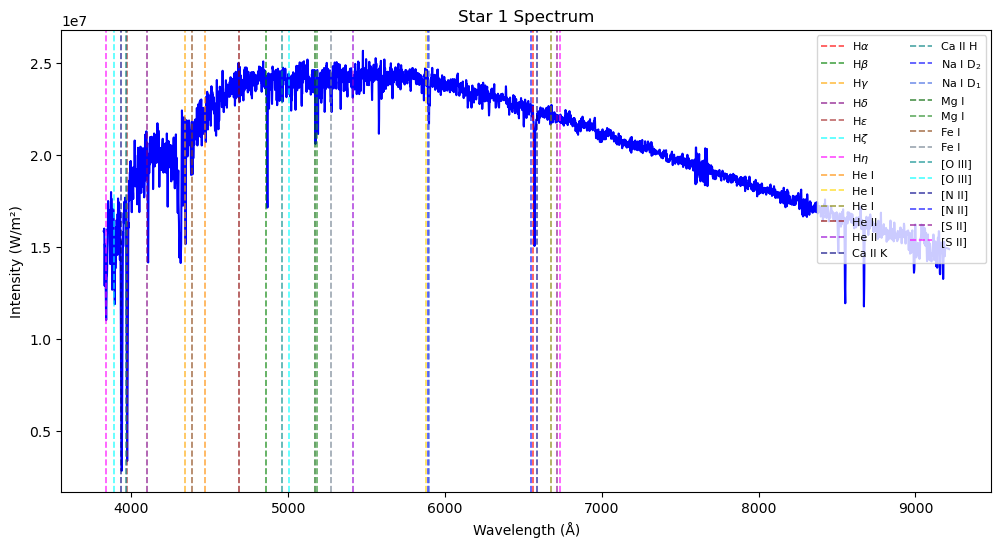

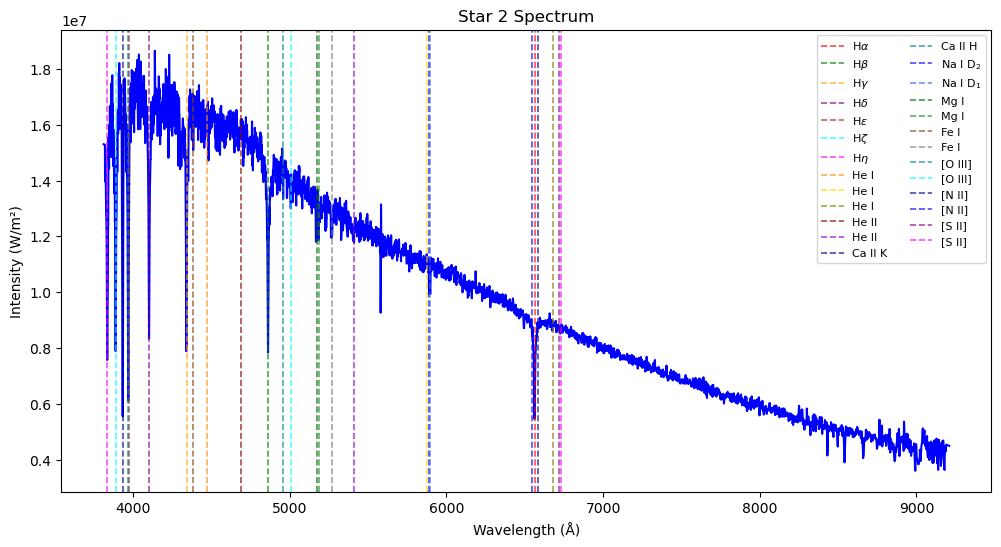

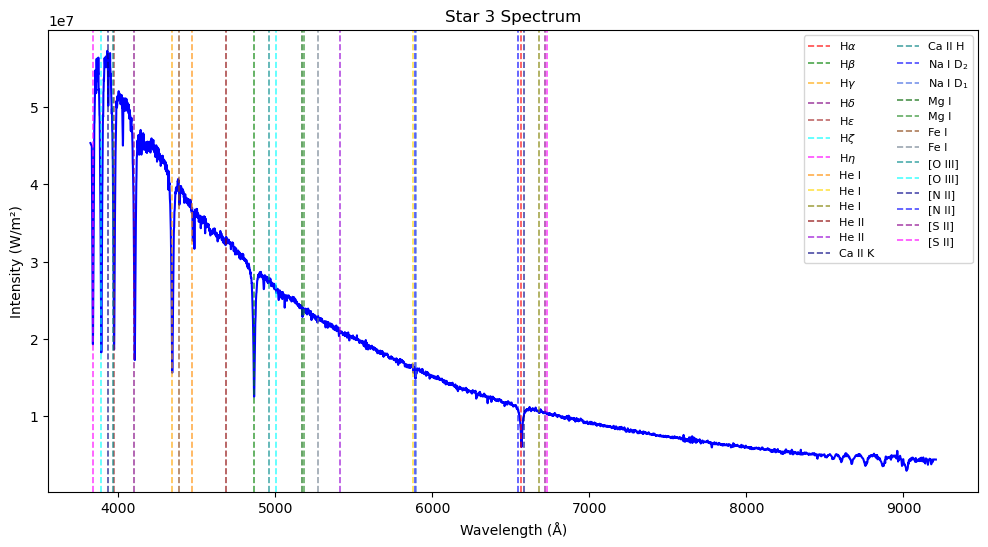

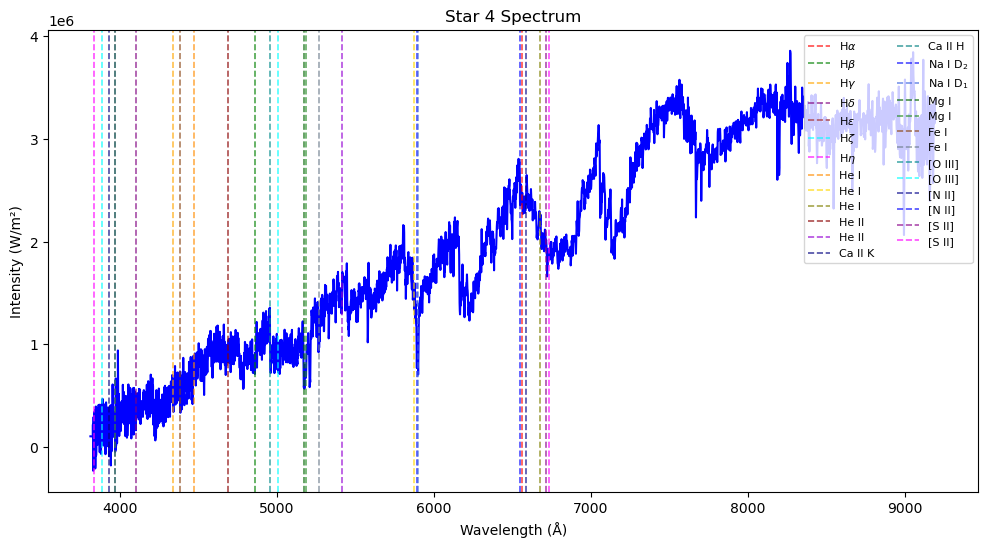

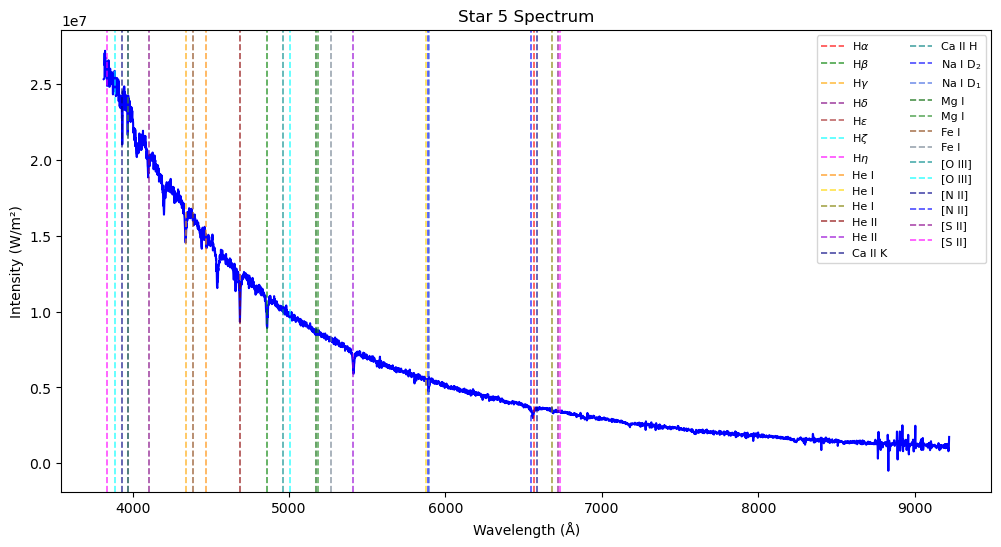

In [238]:
plot_spectrum_1(wavelengths, data, "Wavelength (Å)", "Intensity (W/m²)", "Spectrum of Stars")

# Blackbody spectra interpretation of the absorption lines

1. Star 1
The star definitely has visible absorption lines on all the labelled Balmer line wavelengths. The star has very strong absorption lines. The strongest Balmer line in the diagram is the H $\epsilon$ line as it has the steepest dip. The Balmer lines are dominating over other lines. Ca II lines are present. Mg lines are also present.There are weak Na lines.

2. Star 2
This star also has strong absorption on all the Balmer line wavelength.Similarly, for this star , the strongest absorption line is the H $\epsilon$ .Dominant Hydrogen Balmer lines.

3. Star 3 
This star also has absorption lines. The H $\alpha$ line is weak. The absorption lines have a wider width. Weak Na lines. 

4. Star 4
This star has no absorption lines on the set of Balmer lines. Strong He I lines and  Na lines.

5. Star 5
This star has very weak absorption lines. The H $\epsilon$ , H $\eta$ and H $\zeta$ absorption lines are not present. Dominant weak Balmer lines.



In [239]:
def Wien_approximation(wavelength):
    """
    Calculate the peak wavelength using Wien's approximation.

    Parameters:
    wavelength (float): Wavelength in meters.
    temperature (float): Temperature in Kelvin.

    Returns:
    float: Peak wavelength in meters.
    """
    b = 2.897771955e-3  # Wien's displacement constant in m*K
    temperature = b / wavelength
    return temperature

In [240]:
max_indices = [np.argmax(d) for d in data]
max_wavelengths = [wavelengths[i][idx] for i, idx in enumerate(max_indices)]

temperatures = [Wien_approximation(wl * 1e-10) for wl in max_wavelengths]



In [241]:
from scipy.optimize import curve_fit


def blackbody_fit(wavelength, flux, T_initial):
    
    # Convert wavelength from Angstroms to metres
    wavelength_m = wavelength * 1e-10
    
    # Convert FITS flux from
    # erg / (cm s Angstrom) -> W / m^3
    flux_SI = flux * 1e5

    
   
    def model(wavelength, T, A):
        
        h = 6.62607015e-34
        c = 3.0e8
        k = 1.380649e-23
        
        exponent = (h * c) / (wavelength * k * T)
        
        B = (
            (2.0 * h * c**2) /
            (wavelength**5)
            /
            np.expm1(exponent)
        )
        
        return A * B
    
    
    
    B_initial = model(wavelength_m, T_initial, 1.0)
    
    A_initial = np.max(flux_SI) / np.max(B_initial)
    
    
   
    popt, pcov = curve_fit(
        model,
        wavelength_m,
        flux_SI,
        p0=[T_initial, A_initial],
        bounds=(
            [1000, 0],
            [100000, np.inf]
        ),
        maxfev=50000
    )
    
    
    T_fit, A_fit = popt
    
    return T_fit, A_fit, model(wavelength_m, T_fit, A_fit)

In [242]:
wien_temperatures = []

for wavelength_max in max_wavelengths:
    
    wavelength_max_m = wavelength_max * 1e-10
    
    T_wien = Wien_approximation(wavelength_max_m)
    
    wien_temperatures.append(T_wien)

In [243]:
fitted_temperatures = []
fitted_models = []

for i in range(len(data)):
    
    T_wien = wien_temperatures[i]
    
    T_fit, A_fit, model_flux = blackbody_fit(
        wavelengths[i],
        data[i],
        T_wien
    )
    
    fitted_temperatures.append(T_fit)
    fitted_models.append(model_flux)
    
    print(
        f"Star {i+1}: "
        f"Wien T = {T_wien:.0f} K, "
        f"Fitted T = {T_fit:.0f} K"
    )

Star 1: Wien T = 5291 K, Fitted T = 5217 K
Star 2: Wien T = 7003 K, Fitted T = 7508 K
Star 3: Wien T = 7373 K, Fitted T = 15063 K
Star 4: Wien T = 3505 K, Fitted T = 3092 K
Star 5: Wien T = 7578 K, Fitted T = 48987 K


 The code above shows the estimation of the temperature of the star from the fitted blackbody spectrum. The printed results above show the estimation from Wiens law which was used as an initial condition for the fitting method in scipy.The fitting method was used to find the best fit balckbody spectrum for the observed stellar spectrum.  Then the results on the right are the temperature values that gives the best fit for the blackbody spectrum.

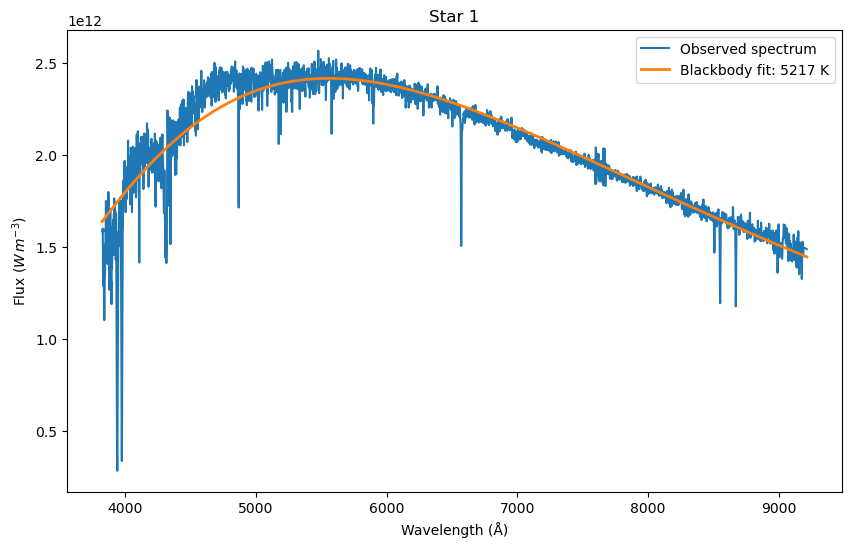

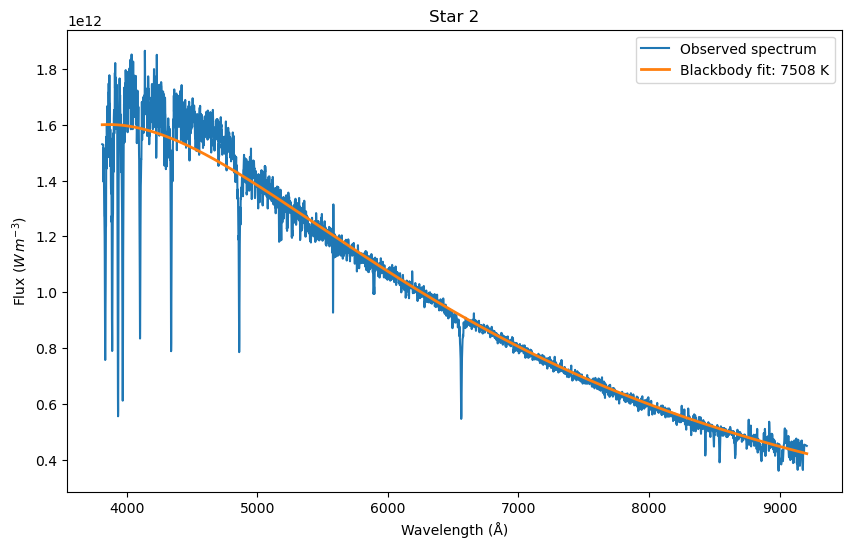

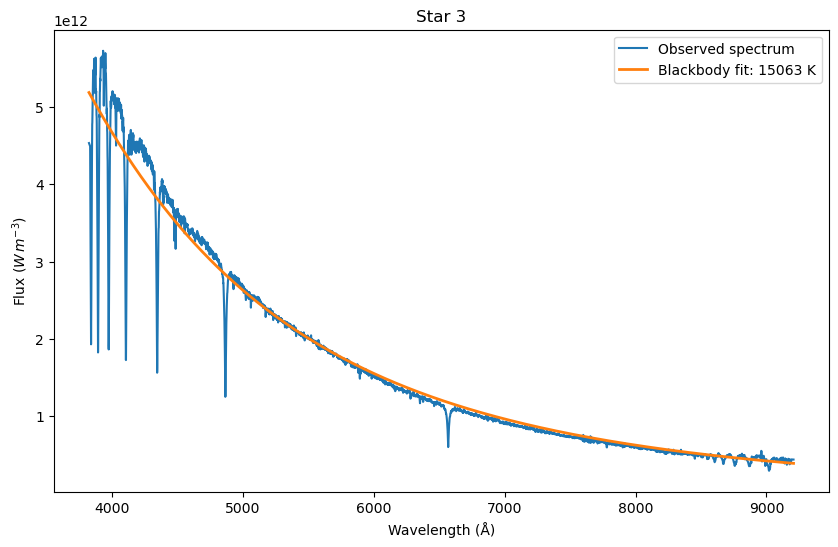

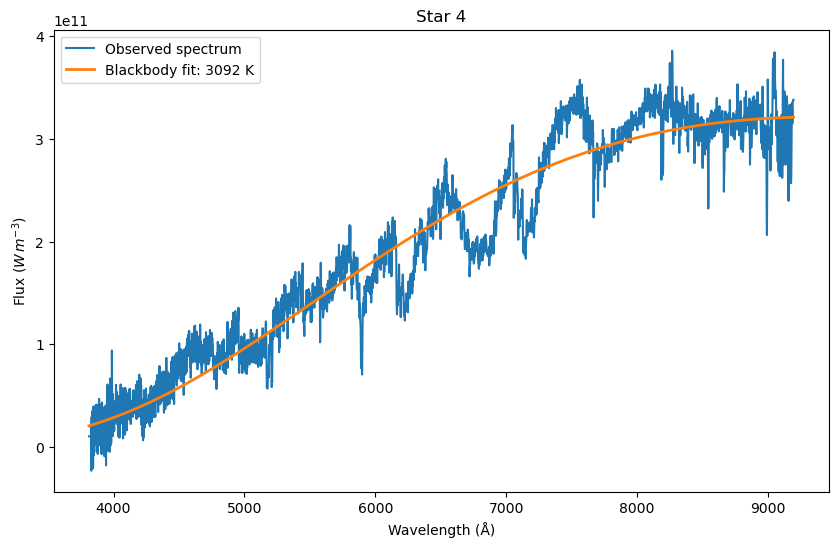

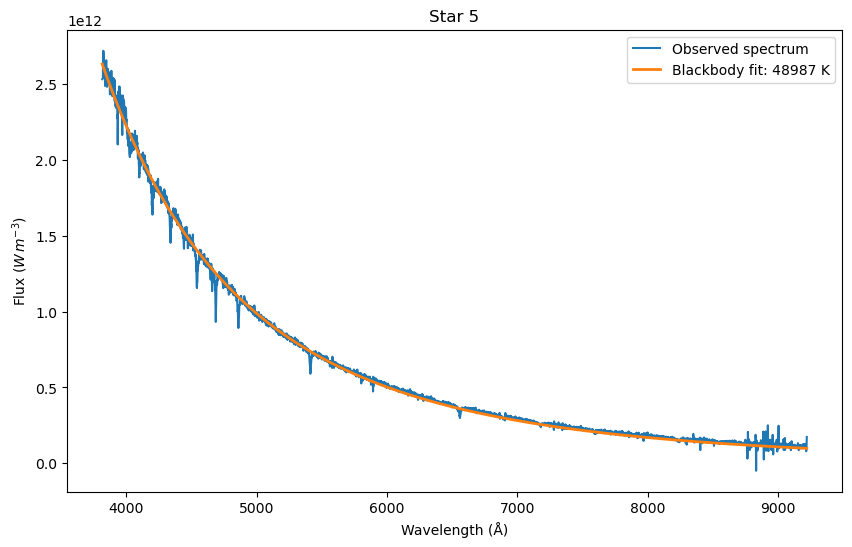

In [244]:
for i in range(len(data)):
    
    wavelength_nm = wavelengths[i]
    
    flux_SI = data[i] * 1e5
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(
        wavelength_nm,
        flux_SI,
        label="Observed spectrum"
    )
    
    plt.plot(
        wavelength_nm,
        fitted_models[i],
        label=f"Blackbody fit: {fitted_temperatures[i]:.0f} K",
        linewidth=2
    )
    
    plt.xlabel("Wavelength (Å)")
    plt.ylabel(r"Flux ($W\,m^{-3}$)")
    
    plt.title(f"Star {i+1}")
    
    plt.legend()
    plt.show()

###  The plots above give the observed spectra with the fitted balckbody spectra.

# Spetral class of each star

1. Star 1 :

The spectral class of star is a G-type. This is because the predicted temperature of the star from the blackbody fitting method is in the temperature range of the G spectral class from Question 2 . It has dominant Balmer lines but also has Mg lines ,Na lines and Ca II lines.

2. Star 2 :

The spectral class of the star is spectral class  A . The reason is that it is because of the temperature range is in the range of spectral class A.Has dominant Balmer lines and very weak Na and NII lines. 

3. Star 3 :

The spectral class of the star is spectral class B. The reason is that temperature is in the temperature range of spectral class of B. Balmer lines are dominant. Has very weak He II. 

4. Star 4 :

The spectral class of the star is M type. This is because the predicted temperature is in the temperature of the spectral class M. Strong Na lines. 

5. Star 5 :

The spectral class of the star is K type. The reason is is because the predicted temperature is in the temperature of the spectral class K . Very weak Balmer lines. 

# Question 4



In [245]:
flux_SI = 1e-7 / (1e-2 * 1e-10)  # factor to convert flux from erg/s/cm²/Å to W/m²/m
data = []  # flux values for each file
wavelengths =[]  # wavelength values for each file
files =['qso_template32.fit']  # reading the FITS files
i=0
for file in files:
    hd_1 = fits.open(file)
    data.append(flux_SI * hd_1[0].data[0]) # Assuming the data is in the first extension
    print(hd_1[0].header)  # Print the header to check for wavelength information


    c_0 = hd_1[0].header['coeff0']  # Starting wavelength value from the FITS header
    c_1 = hd_1[0].header['coeff1']  # Wavelength increment from the FITS header
    j =np.arange(len(data[i]))  # Create an array of indices corresponding to the data points

    wavelength = 10**(c_0 +c_1*j)
    wavelengths.append(wavelength)
    i+=1

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 6874                                                  NAXIS2  =                    4                                                  PIXMIN  = 0.00000000000000E+00 / Place Holder                                   PIXMAX  = 3.55400000000000E+03 / Place Holder                                   NWORDER =                    2 / Linear-log10 coefficients                      WFITTYPE= 'LOG_LINEAR'         / Linear-Log10 dispersion                        VERS_1D = 'not1d   '           / Version of Spectro1d                           EXTEND  =                    T / Binary tables follow                           COEFF0  = 3.13043120000000E+00 / Center wavelength (log10) of first pi          COEFF1  = 1.00000000000000E-04 / Log10 d

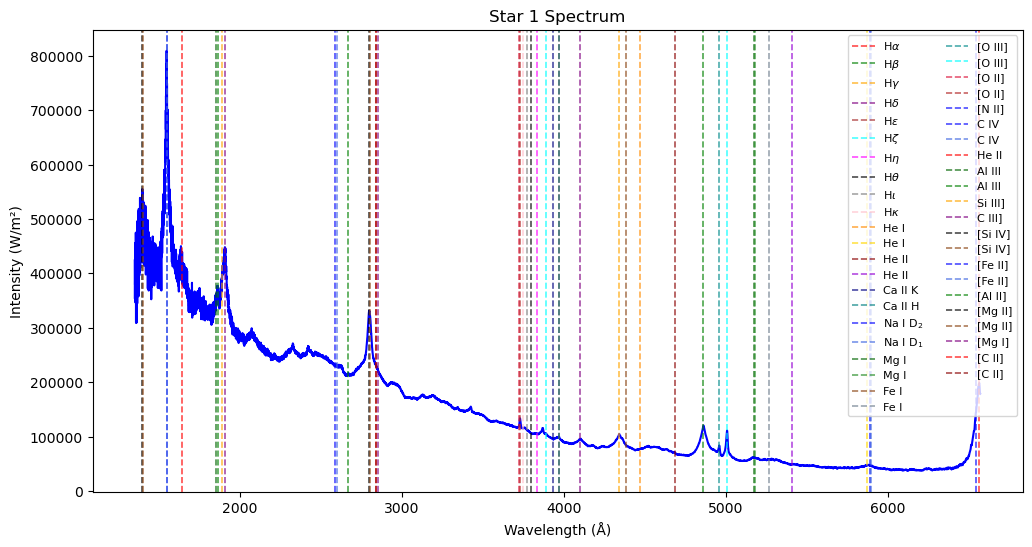

In [246]:
plot_spectrum_1(wavelengths, data, "Wavelength (Å)", "Intensity (W/m²)", "QSO Template Spectrum")

In [247]:
df = pd.read_csv('sourceA.csv')

wavelengths_sourceA = df['Wavelength'].values
flux_sourceA = df['Flux'].values

In [248]:
def plot_spectrum(wavelength, intensity, xlabel, ylabel, title):
    """
    Plot the spectrum data.

    Parameters:
    wavelength (array-like): Wavelength data.
    intensity (array-like): Intensity data.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    title (str): Title of the plot.
    """
    balmer_lines = {                           # balmer series lines with their corresponding colors
        6562.8: (r'H$\alpha$', 'red'),
        4861.3: (r'H$\beta$', 'green'),
        4340.5: (r'H$\gamma$', 'orange'),
        4101.7: (r'H$\delta$', 'purple'),
        3970.1: (r'H$\epsilon$', 'brown'),
        3889.1: (r'H$\zeta$', 'cyan'),
        3835.4: (r'H$\eta$', 'magenta'),
        3797.9: (r'H$\theta$', 'black'),
        3770.6: (r'H$\iota$', 'gray'),
        3750.2: (r'H$\kappa$', 'pink')
    }
    
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Star {i+1} Spectrum")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.plot(wavelength,intensity, color='blue')
    for wl, (label, colour) in balmer_lines.items():
            if wavelength[i].min() <= wl <= wavelength[i].max():
                    plt.axvline(
                        wl,
                        color=colour,
                        linestyle='--',
                        linewidth=1.5,
                        alpha=0.8,
                        label=label
                    )
    plt.legend()

    plt.show()

/tmp/ipykernel_103578/168333688.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


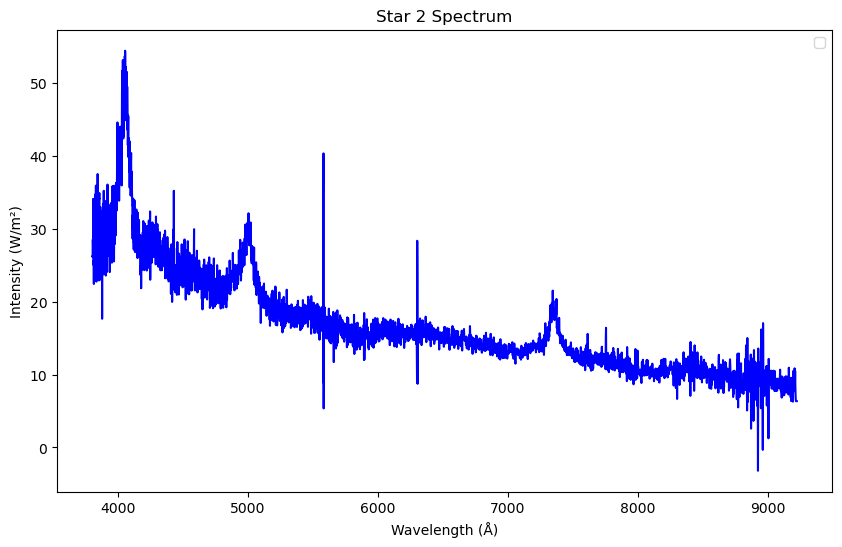

In [249]:
plot_spectrum(wavelengths_sourceA, flux_sourceA , "Wavelength (Å)", "Intensity (W/m²)", "Source A Spectrum")